# Phase 4: Expirementation with Kronecker Sequences

First we must import

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
import matplotlib.ticker as mtick
from collections import Counter
from dataclasses import dataclass, asdict



# Import Calculations for Zaremba Index
from math_help import rho_box1_numpy, rho_box_bruteforce, rho_box_lyness, rho_3d_lyness, generate_optimized_g_vectors_3d, rho_4d_lyness, rho_5d_lyness, generate_optimized_g_vectors_4d, generate_optimized_g_vectors_5d

# Import Dataframe Helper
from experiment import bound_sufficiency_df

From the old study we know that - $\frac{C_d N}{(\log N)^{d-1}}$ : Is more of a theoretical lower-bound scale / existence-type benchmark

Our goal is to:
- Understand the distribution of $\rho_d(N,g)$
- Understand how the worst, median, and possibly upper quantiles behave w/ N
- Compare empirical behaviour against theoretical scaling
- Do this in 3D, 4D, and 5D

First let's setup the basic helper functions that are going to be using for this experiment


In [7]:
def get_rho_function(d):
    if d == 3:
        return rho_3d_lyness
    elif d == 4:
        return rho_4d_lyness
    elif d == 5:
        return rho_5d_lyness
    else:
        raise ValueError(f"Unsupported dimension: {d}")


def get_generator_function(d):
    if d == 3:
        return generate_optimized_g_vectors_3d
    elif d == 4:
        return generate_optimized_g_vectors_4d
    elif d == 5:
        return generate_optimized_g_vectors_5d
    else:
        raise ValueError(f"Unsupported dimension: {d}")
    

def total_generator_space_prime(N, d):
    """
    For prime N, with g1 fixed at 1, the full generator space has size:
        (N - 1)^(d - 1)
    """
    return (N - 1) ** (d - 1)

def weighted_quantile(values, weights, quantiles):
    """
    Compute weighted quantiles.

    Parameters
    ----------
    values : array-like
    weights : array-like
    quantiles : scalar or array-like in [0, 1]

    Returns
    -------
    np.ndarray
    """
    values = np.asarray(values)
    weights = np.asarray(weights)
    quantiles = np.atleast_1d(quantiles)

    if len(values) == 0:
        raise ValueError("No values provided.")
    if np.any(weights < 0):
        raise ValueError("Weights must be nonnegative.")
    if np.sum(weights) == 0:
        raise ValueError("Weights sum to zero.")

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cum_weights = np.cumsum(weights)
    total_weight = cum_weights[-1]
    quantile_positions = quantiles * total_weight

    return np.interp(quantile_positions, cum_weights, values)

def summarize_rho_distribution(df, N, d):
    """
    Summarize the weighted distribution of rho values for one fixed (N, d).

    Expects df to contain columns:
        - rho
        - weight
    """
    values = df["rho"].to_numpy()
    weights = df["weight"].to_numpy()

    q10, q25, q50, q75, q90 = weighted_quantile(
        values, weights, [0.10, 0.25, 0.50, 0.75, 0.90]
    )

    return {
        "dimension": d,
        "N": N,
        "num_reduced_generators": len(df),
        "weighted_total_generators": int(df["weight"].sum()),
        "rho_min": float(np.min(values)),
        "rho_q10": float(q10),
        "rho_q25": float(q25),
        "rho_median": float(q50),
        "rho_q75": float(q75),
        "rho_q90": float(q90),
        "rho_max": float(np.max(values)),
        "rho_mean_weighted": float(np.average(values, weights=weights)),
    }
    

def collect_rho_distribution(N, d, verbose=True):
    """
    Compute rho for all symmetry-reduced generators for one fixed (N, d).

    Returns
    -------
    df : pandas.DataFrame
        One row per reduced generator
    summary : dict
        Weighted summary statistics
    """
    rho_func = get_rho_function(d)
    generator_func = get_generator_function(d)

    rows = []
    start_time = time.time()

    for g_vector, weight in generator_func(N):
        alpha_vector = tuple(g / N for g in g_vector[1:])
        rho_value, aux = rho_func(N, alpha_vector)

        rows.append({
            "dimension": d,
            "N": N,
            "g_vector": tuple(g_vector),
            "alpha_vector": alpha_vector,
            "rho": float(rho_value),
            "weight": int(weight),
            "aux": aux
        })

    df = pd.DataFrame(rows)
    summary = summarize_rho_distribution(df, N, d)
    summary["elapsed_seconds"] = time.time() - start_time

    if verbose:
        print(f"[DONE] d = {d}, N = {N}")
        print(f"  Reduced generators: {summary['num_reduced_generators']}")
        print(f"  Weighted total generators: {summary['weighted_total_generators']}")
        print(f"  rho_min:    {summary['rho_min']}")
        print(f"  rho_median: {summary['rho_median']}")
        print(f"  rho_max:    {summary['rho_max']}")
        print(f"  elapsed:    {summary['elapsed_seconds']:.2f} s\n")

    return df, summary

def rho_counter_from_reduced_enumeration(N, d):
    """
    Count rho frequencies using symmetry-reduced enumeration, expanded by weights.
    """
    rho_func = get_rho_function(d)
    generator_func = get_generator_function(d)

    counter = Counter()

    for g_vector, weight in generator_func(N):
        alpha_vector = tuple(g / N for g in g_vector[1:])
        rho_value, _ = rho_func(N, alpha_vector)
        counter[float(rho_value)] += int(weight)

    return counter

Constants

In [9]:
DIMS = [3, 4, 5]

# Representative N values for histogram/distribution inspection
HISTOGRAM_NS_3D = [101, 251, 503]
HISTOGRAM_NS_4D = [11, 17, 23]
HISTOGRAM_NS_5D = [7, 11, 13]

# N values for scaling/regression
SCALING_NS_3D = [29, 43, 59, 83, 101, 151, 251, 503, 1009]
SCALING_NS_4D = [7, 11, 13, 17, 19, 23, 29]
SCALING_NS_5D = [5, 7, 11, 13, 17]



Now that we have everthing lets run the histogram experiment

In [10]:
histogram_results = {}

for N in HISTOGRAM_NS_3D:
    
    df, summary = collect_rho_distribution(N, 3)
    
    histogram_results[(3, N)] = (df, summary)

pd.DataFrame([summary for _, summary in histogram_results.values()])

[DONE] d = 3, N = 101
  Reduced generators: 5050
  Weighted total generators: 10000
  rho_min:    1.0
  rho_median: 101.0
  rho_max:    101.0
  elapsed:    0.13 s

[DONE] d = 3, N = 251
  Reduced generators: 31375
  Weighted total generators: 62500
  rho_min:    1.0
  rho_median: 251.0
  rho_max:    251.0
  elapsed:    2.94 s

[DONE] d = 3, N = 503
  Reduced generators: 126253
  Weighted total generators: 252004
  rho_min:    1.0
  rho_median: 503.0
  rho_max:    503.0
  elapsed:    19.42 s



,dimension,N,num_reduced_generators,weighted_total_generators,rho_min,rho_q10,rho_q25,rho_median,rho_q75,rho_q90,rho_max,rho_mean_weighted,elapsed_seconds
0,3,101,5050,10000,1.0,30.0,63.0,101.0,101.0,101.0,101.0,81.430000,0.133383
1,3,251,31375,62500,1.0,116.0,251.0,251.0,251.0,251.0,251.0,223.244032,2.938356
2,3,503,126253,252004,1.0,352.0,503.0,503.0,503.0,503.0,503.0,467.978588,19.424214


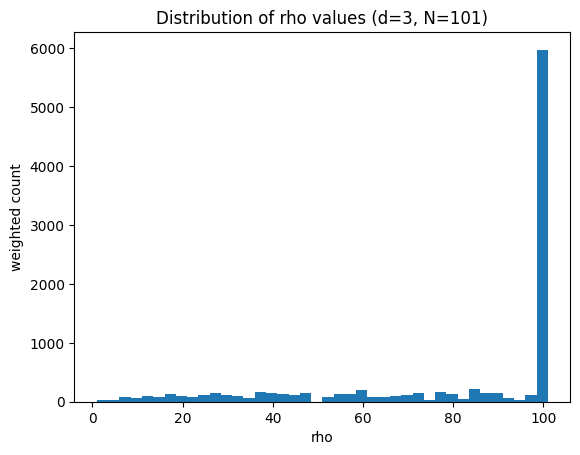

In [17]:
df = histogram_results[(3, 101)][0]

plt.hist(df["rho"], bins=40, weights=df["weight"])
plt.title("Distribution of rho values (d=3, N=101)")
plt.xlabel("rho")
plt.ylabel("weighted count")
plt.show()

The histogram of $\rh$o values for d=3 reveals a highly skewed distribution with a strong concentration near the maximum possible value $\rho$ = N. While values of $\rho$ occur across a wide range, a large fraction of generating vectors produce the maximal Zaremba index. This is reflected in the summary statistics: for N=101, both the median and upper quantiles (75th and 90th percentiles) equal 101, indicating that at least half of all generating vectors achieve the maximal possible value of $\rho$. Similar behavior appears for larger N, where the distribution becomes increasingly concentrated near N.

These observations suggest that although poor generating vectors exist, they form a relatively small portion of the generator space. Most generating vectors appear to produce lattices with very large Zaremba index values, indicating strong geometric quality for the corresponding dual lattice. In particular, the presence of a sharp spike at $\rho$ = N in the histogram indicates that maximal Zaremba index values occur very frequently among generators.

In [13]:
scaling_summaries = []

for N in SCALING_NS_3D:
    
    df, summary = collect_rho_distribution(N, 3)
    
    scaling_summaries.append(summary)

scaling_df = pd.DataFrame(scaling_summaries)
scaling_df


[DONE] d = 3, N = 29
  Reduced generators: 406
  Weighted total generators: 784
  rho_min:    1.0
  rho_median: 18.000000000000036
  rho_max:    29.0
  elapsed:    0.00 s

[DONE] d = 3, N = 43
  Reduced generators: 903
  Weighted total generators: 1764
  rho_min:    1.0
  rho_median: 33.00000000000006
  rho_max:    43.0
  elapsed:    0.01 s

[DONE] d = 3, N = 59
  Reduced generators: 1711
  Weighted total generators: 3364
  rho_min:    1.0
  rho_median: 53.99999999999986
  rho_max:    59.0
  elapsed:    0.03 s

[DONE] d = 3, N = 83
  Reduced generators: 3403
  Weighted total generators: 6724
  rho_min:    1.0
  rho_median: 83.0
  rho_max:    83.0
  elapsed:    0.08 s

[DONE] d = 3, N = 101
  Reduced generators: 5050
  Weighted total generators: 10000
  rho_min:    1.0
  rho_median: 101.0
  rho_max:    101.0
  elapsed:    0.13 s

[DONE] d = 3, N = 151
  Reduced generators: 11325
  Weighted total generators: 22500
  rho_min:    1.0
  rho_median: 151.0
  rho_max:    151.0
  elapsed:    0.

,dimension,N,num_reduced_generators,weighted_total_generators,rho_min,rho_q10,rho_q25,rho_median,rho_q75,rho_q90,rho_max,rho_mean_weighted,elapsed_seconds
0,3,29,406,784,1.0,6.0,10.0,18.0,27.0,29.0,29.0,18.127551,0.004462
1,3,43,903,1764,1.0,10.0,18.0,33.0,43.0,43.0,43.0,29.689342,0.012507
2,3,59,1711,3364,1.0,14.0,28.0,54.0,59.0,59.0,59.0,43.620690,0.028680
3,3,83,3403,6724,1.0,24.0,48.0,83.0,83.0,83.0,83.0,64.879833,0.075125
4,3,101,5050,10000,1.0,30.0,63.0,101.0,101.0,101.0,101.0,81.430000,0.132237
5,3,151,11325,22500,1.0,54.0,120.0,151.0,151.0,151.0,151.0,128.034667,0.448107
6,3,251,31375,62500,1.0,116.0,251.0,251.0,251.0,251.0,251.0,223.244032,2.604008
7,3,503,126253,252004,1.0,352.0,503.0,503.0,503.0,503.0,503.0,467.978588,20.930588
8,3,1009,508536,1016064,1.0,1009.0,1009.0,1009.0,1009.0,1009.0,1009.0,965.753189,150.043016


The table summarizing the distribution of $\rho$ values across increasing N shows a clear scaling trend. The minimum Zaremba index remains constant at $\rho_{\min}$=1, confirming that pathological generators exist for all tested values of N. However, the median and upper quantiles grow rapidly with N. For sufficiently large N, the median Zaremba index is approximately equal to N, indicating that a typical generating vector produces a lattice whose shortest dual vector length is close to the maximal possible value.

The weighted mean Zaremba index also increases approximately linearly with N. For example, when N=101, the mean value is approximately 81, while for N=503 it rises to approximately 468, and for N=1009 it approaches 966. This suggests that as N increases, the average generator quality improves and approaches the maximal achievable value.

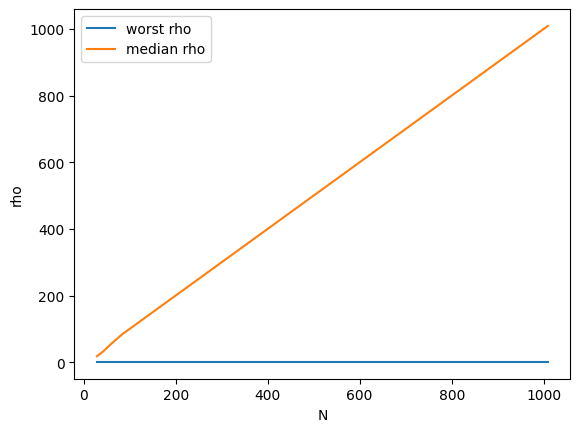

In [14]:
plt.plot(scaling_df["N"], scaling_df["rho_min"], label="worst rho")
plt.plot(scaling_df["N"], scaling_df["rho_median"], label="median rho")

plt.xlabel("N")
plt.ylabel("rho")
plt.legend()
plt.show()

The scaling plot comparing the worst-case and median values of $\rho$ illustrates two very different behaviors. The worst-case Zaremba index remains essentially constant at $\rho_{\min}$=1, indicating that extremely poor generators persist regardless of how large N becomes. In contrast, the median Zaremba index grows approximately linearly with N. This divergence highlights the difference between worst-case and typical generator behavior.

The linear growth of the median suggests that most generators produce lattices whose Zaremba index scales proportionally with N. In other words, the typical generator appears to yield near-optimal dual lattice spacing. This empirical observation suggests that randomly selected generators are highly likely to produce high-quality lattices.

Lets plot the histogram now but make them weighted??

First some helpers